# BÀI TẬP 2 - CNN: Nhận dạng Cat vs Dog
**Dataset:** TensorFlow Datasets - cats_vs_dogs (public)
**Labels:** 0 = Cat, 1 = Dog

In [1]:
# BƯỚC 1: NẠP THƯ VIỆN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import tensorflow_datasets as tfds
import keras
from keras.models import Sequential
from keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout, Input
from sklearn.metrics import classification_report, confusion_matrix
print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


In [2]:
# BƯỚC 2: TẢI VÀ XỬ LÝ DỮ LIỆU
IMG_SIZE = (64, 64)
class_names = ['Cat', 'Dog']
input_shape = (64, 64, 3)

def preprocess_img(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

ds_train = tfds.load('cats_vs_dogs', split='train[:80%]', as_supervised=True)
ds_test  = tfds.load('cats_vs_dogs', split='train[80%:]', as_supervised=True)

BATCH = 32
ds_train = ds_train.map(preprocess_img).shuffle(1000).batch(BATCH).prefetch(tf.data.AUTOTUNE)
ds_test  = ds_test.map(preprocess_img).batch(BATCH).prefetch(tf.data.AUTOTUNE)

# Lấy numpy để visualize và evaluate
X_test_np = np.concatenate([X.numpy() for X, y in ds_test])
y_test_np = np.concatenate([y.numpy() for X, y in ds_test])
print('X_test:', X_test_np.shape, '| y_test:', y_test_np.shape)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.NE8JPU_4.0.1/cats_vs_dogs-train.tfrecord-[0-9][0-9…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.
X_test: (4652, 64, 64, 3) | y_test: (4652,)


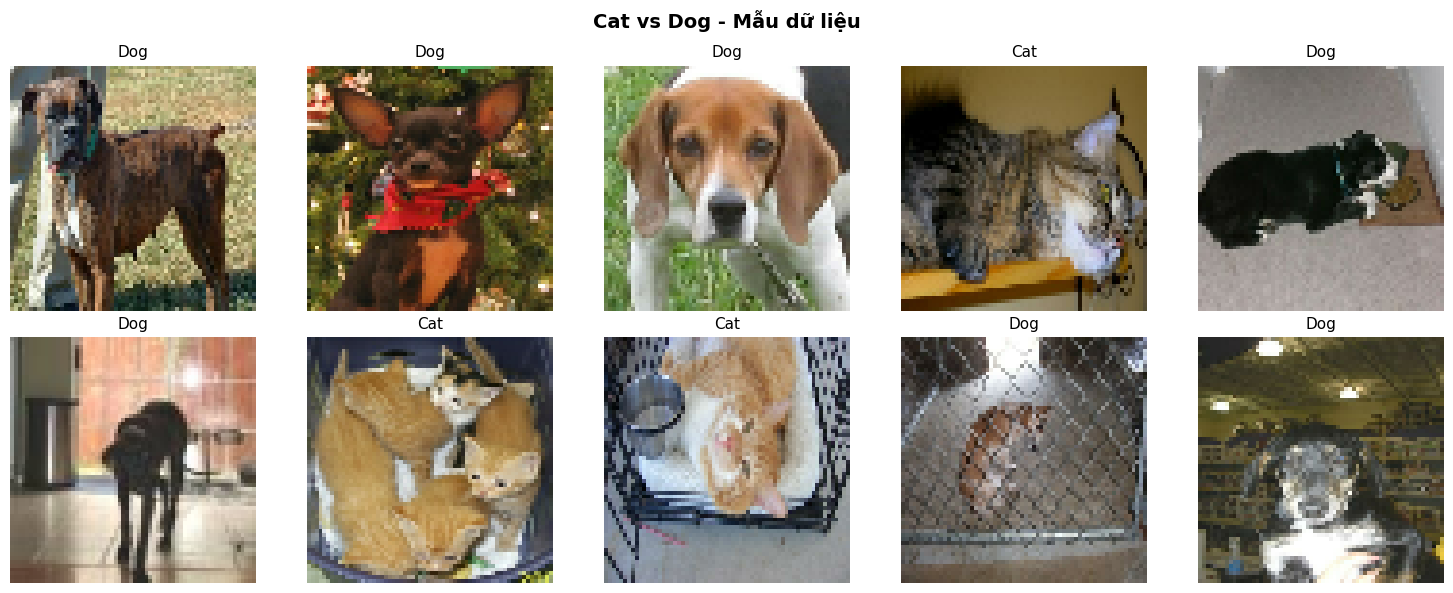

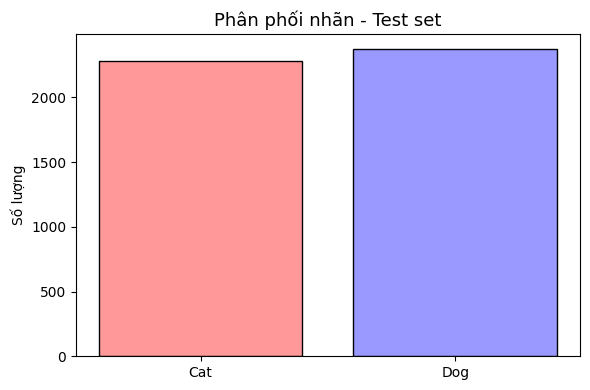

In [3]:
# BƯỚC 3: TRỰC QUAN HÓA DỮ LIỆU
ds_show = tfds.load('cats_vs_dogs', split='train[:10]', as_supervised=True)
imgs, lbls = [], []
for img, lbl in ds_show:
    imgs.append(tf.image.resize(img, IMG_SIZE).numpy().astype('uint8'))
    lbls.append(lbl.numpy())

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.ravel()
for i in range(10):
    axes[i].imshow(imgs[i])
    axes[i].set_title(class_names[lbls[i]], fontsize=11)
    axes[i].axis('off')
plt.suptitle('Cat vs Dog - Mẫu dữ liệu', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Phân phối nhãn
unique, counts = np.unique(y_test_np, return_counts=True)
plt.figure(figsize=(6, 4))
plt.bar([class_names[i] for i in unique], counts,
        color=['#FF9999','#9999FF'], edgecolor='black')
plt.title('Phân phối nhãn - Test set', fontsize=13)
plt.ylabel('Số lượng')
plt.tight_layout(); plt.show()

In [4]:
# BƯỚC 4: XÂY DỰNG MÔ HÌNH CNN
model = Sequential([
    Input(shape=input_shape),
    Conv2D(32, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(64, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Conv2D(128, kernel_size=(3,3), activation='relu'),
    MaxPool2D(pool_size=(2,2)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(1, activation='sigmoid')  # Binary classification
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,273,409 (4.86 MB)

 Trainable params: 1,273,409 (4.86 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# BƯỚC 5: HUẤN LUYỆN MÔ HÌNH
model_fit = model.fit(ds_train,
                      validation_data=ds_test,
                      epochs=15,
                      verbose=1)

Epoch 1/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 192s 324ms/step - accuracy: 0.6384 - loss: 0.6228 - val_accuracy: 0.7466 - val_loss: 0.5198
Epoch 2/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 184s 314ms/step - accuracy: 0.7594 - loss: 0.4957 - val_accuracy: 0.7837 - val_loss: 0.4551
Epoch 3/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 184s 315ms/step - accuracy: 0.8040 - loss: 0.4251 - val_accuracy: 0.8138 - val_loss: 0.4053
Epoch 4/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 190s 325ms/step - accuracy: 0.8371 - loss: 0.3641 - val_accuracy: 0.7846 - val_loss: 0.4790
Epoch 5/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 178s 304ms/step - accuracy: 0.8602 - loss: 0.3172 - val_accuracy: 0.8325 - val_loss: 0.3764
Epoch 6/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 170s 291ms/step - accuracy: 0.8858 - loss: 0.2674 - val_accuracy: 0.8362 - val_loss: 0.3910
Epoch 7/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 176s 299ms/step - accuracy: 0.9078 - loss: 0.2233 - val_accuracy: 0.8390 - val_loss: 0.3994
Epoch 8/15
582/582 ━━━━━━━━━━━━━━━━━━━━ 211s 316ms/step - accuracy: 0.9274 -

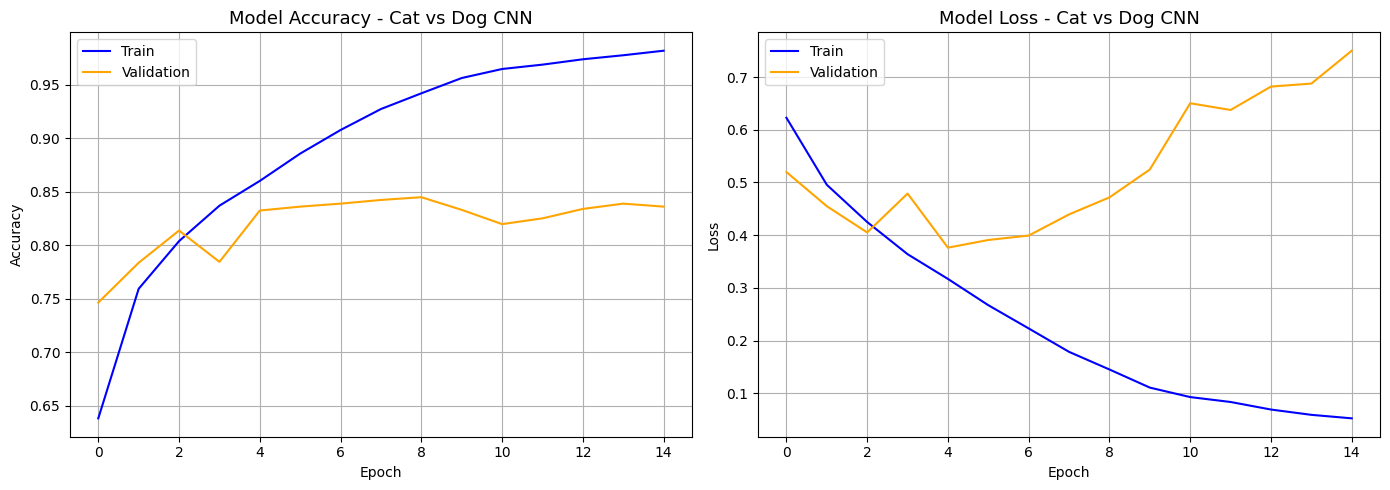

In [6]:
# BƯỚC 6: BIỂU ĐỒ ACCURACY & LOSS
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(model_fit.history['accuracy'], label='Train', color='blue')
axes[0].plot(model_fit.history['val_accuracy'], label='Validation', color='orange')
axes[0].set_title('Model Accuracy - Cat vs Dog CNN', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(model_fit.history['loss'], label='Train', color='blue')
axes[1].plot(model_fit.history['val_loss'], label='Validation', color='orange')
axes[1].set_title('Model Loss - Cat vs Dog CNN', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()

146/146 - 10s - 65ms/step - accuracy: 0.8362 - loss: 0.7499
Test loss:     0.7498535513877869
Test accuracy: 0.8361994624137878
146/146 ━━━━━━━━━━━━━━━━━━━━ 10s 68ms/step

=== Classification Report ===
              precision    recall  f1-score   support

         Cat       0.86      0.80      0.83      2280
         Dog       0.82      0.87      0.84      2372

    accuracy                           0.84      4652
   macro avg       0.84      0.84      0.84      4652
weighted avg       0.84      0.84      0.84      4652



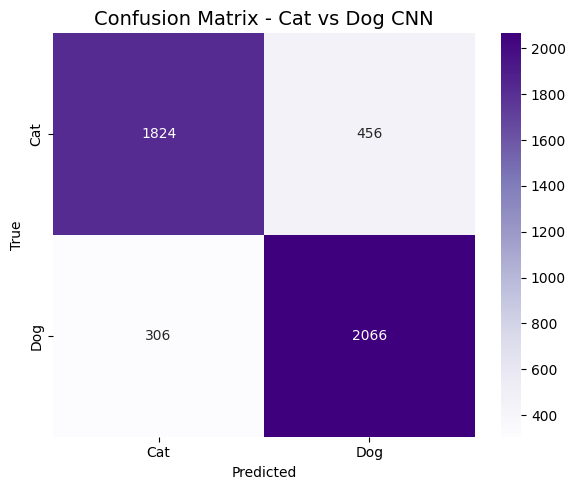

In [7]:
# BƯỚC 7: ĐÁNH GIÁ VÀ CONFUSION MATRIX
score = model.evaluate(X_test_np, y_test_np, verbose=2)
print('Test loss:    ', score[0])
print('Test accuracy:', score[1])

y_pred = (model.predict(X_test_np) > 0.5).astype(int).flatten()
print('\n=== Classification Report ===')
print(classification_report(y_test_np, y_pred, target_names=class_names))

cm = confusion_matrix(y_test_np, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Cat vs Dog CNN', fontsize=14)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Predicted: Dog | True: Dog


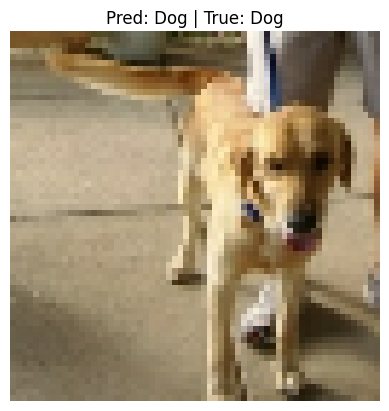

Đã lưu weights!


In [8]:
# BƯỚC 8: DỰ BÁO ẢNH MỚI
predict = model.predict(X_test_np[:1])
pred_label = int(predict[0][0] > 0.5)
print('Predicted:', class_names[pred_label], '| True:', class_names[y_test_np[0]])
plt.imshow(X_test_np[0])
plt.title(f'Pred: {class_names[pred_label]} | True: {class_names[y_test_np[0]]}')
plt.axis('off'); plt.show()

# LƯU MODEL
model.save_weights('cnn_catdog.weights.h5')
print('Đã lưu weights!')